## Cum Sum Notebook ##

Calculate the yearly cumulative sum of transport entering SoG deeper than 100 m

In [45]:
import arrow
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [9]:
section = 2
thedir = '/data/sallen/results/Ariane/v202111/FullSouth/'
years = [2015, 2017, 2020]

Patch bad dates

In [28]:
bad_dates = [dt.datetime(2015, 1, 31), dt.datetime(2020, 8, 6)]
trans_for_bad = {}
for r in bad_dates:
    before = arrow.get(r).shift(days=-1)
    filename = (thedir+before.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
    before_data = xr.open_dataset(filename)
    before_deep_transports = np.sum(before_data.final_transp[(before_data.final_section==section) &
                                                    (before_data.final_depth <= -100)])/24.

    after = arrow.get(r).shift(days=+1)
    filename = (thedir+after.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
    after_data = xr.open_dataset(filename)
    after_deep_transports = np.sum(after_data.final_transp[(after_data.final_section==section) &
                                                    (after_data.final_depth <= -100)])/24.
    print (before_deep_transports, after_deep_transports)
    trans_for_bad[arrow.get(r)] = 0.5*(before_deep_transports + after_deep_transports)

<xarray.DataArray 'final_transp' ()>
array(3404.38420849) <xarray.DataArray 'final_transp' ()>
array(4110.65176075)
<xarray.DataArray 'final_transp' ()>
array(30823.77068297) <xarray.DataArray 'final_transp' ()>
array(30253.05707285)


In [21]:
trans_for_bad.keys()

dict_keys([<Arrow [2015-01-31T00:00:00+00:00]>])

In [30]:
deep_transports = np.zeros((6, 365))
for jj, year in enumerate(years):
    print (year)
    start = dt.datetime(year, 1, 1)
    endtime = dt.datetime(year, 12, 31)
    timerange = [d for d in arrow.Arrow.range('day', start, endtime)
                    if not (d.month == 2 and d.day == 29)]

    for ii, r in enumerate(timerange):
        if r in trans_for_bad.keys():
            print ('here', r)
            deep_transports[jj, ii] = trans_for_bad[r]
        else:
            filename = (thedir+r.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
            mydata = xr.open_dataset(filename)
            deep_transports[jj, ii] = np.sum(mydata.final_transp[(mydata.final_section==section) &
                                                    (mydata.final_depth <= -100)])/24.

2015
here 2015-01-31T00:00:00+00:00
2017
2020
here 2020-08-06T00:00:00+00:00


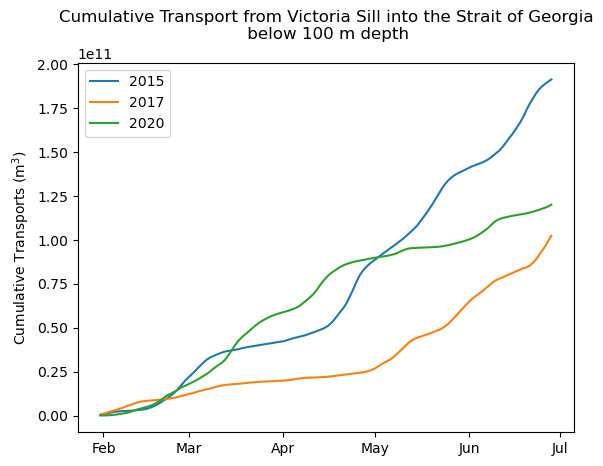

In [55]:
start_day, end_day = 31, 180
day_of_year = np.arange(start_day, end_day)
dates = pd.to_datetime('2015-01-01') + pd.to_timedelta(day_of_year - 1, unit='D')

fig, ax = plt.subplots(1, 1)
ax.plot(dates, np.cumsum(deep_transports[0, start_day:end_day]*86400), label='2015')
ax.plot(dates, np.cumsum(deep_transports[1, start_day:end_day]*86400), label='2017')
ax.plot(dates, np.cumsum(deep_transports[2, start_day:end_day]*86400), label='2020')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend();
ax.set_ylabel('Cumulative Transports (m$^3$)');
ax.set_title('Cumulative Transport from Victoria Sill into the Strait of Georgia\n below 100 m depth');